# DSA 210 Project: Istanbul Weather, Matches, and Public Transport Usage  
### Exploratory Data Analysis, Pairwise Relationships, and Hypothesis Testing

This project investigates how **weather patterns**, **football match days**, and **public transport ridership** interact in Istanbul.  
Using real daily data from:

- Istanbul Municipality Public Transport API  
- MGM Weather Data  
- TFF Match Schedule  

we examine:

1. How each dataset behaves on its own (univariate EDA)  
2. How pairs of variables influence each other (bivariate EDA)  
3. Whether weather + match effects combined can explain transport usage  
4. Hypothesis testing on key questions  
5. Clear visualizations & interpretations  

Our goal is to build a clear understanding of the relationship between environmental and social factors and how they shape mobility in Istanbul.

In [2]:
import os
os.chdir("/workspaces/DSA210-Weather-vs-Transport-Istanbul") 
print(f"Working directory set to: {os.getcwd()}")

Working directory set to: /workspaces/DSA210-Weather-vs-Transport-Istanbul


In [3]:
import os

for root, dirs, files in os.walk("/", topdown=True):
    if "dataexport" in str(files).lower():
        print(root, files)

## 3.1 Daily Weather Dataset – Overview

In this section we explore the daily weather data for Istanbul.  
The dataset contains one row per calendar day with the following variables:

- **Date** – calendar date  
- **temperature_2m (°C)** – mean daily temperature at 2 m height  
- **precipitation (mm)** – total daily precipitation  
- **rain (mm)** – total daily rain amount  
- **is_rainy_day** – indicator (1 = at least some rain, 0 = no rain)

We first load the cleaned dataset, create simple helper columns, and look at the basic statistics.

In [4]:
import pandas as pd

file_path = "data/open-meteo-41.00N28.94E32m.csv"

# Dosyayı satır satır oku
with open(file_path, "r") as f:
    lines = f.readlines()

# İkinci header'ın başladığı satırı bul
start_idx = None
for i, line in enumerate(lines):
    if line.startswith("time,"):
        start_idx = i
        break

# Eğer header bulunduysa, yalnızca hourly kısmı DataFrame olarak yükle
df_weather = pd.read_csv(
    file_path,
    skiprows=start_idx,         # baştaki metadata + boş satırları atla
)

df_weather.head()

,time,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),rain (mm),wind_speed_10m (km/h),visibility (m)
0,2024-01-01T00:00,10.3,89,0.0,0.0,3.8,24140.0
1,2024-01-01T01:00,10.7,86,0.0,0.0,3.1,24140.0
2,2024-01-01T02:00,10.8,83,0.0,0.0,2.6,24140.0
3,2024-01-01T03:00,10.5,86,0.0,0.0,2.6,24140.0
4,2024-01-01T04:00,10.3,86,0.0,0.0,2.5,24140.0


In [5]:
import pandas as pd

# Zaten oluşturduğun df_weather burada olsun
df_weather["Date"] = pd.to_datetime(df_weather["time"])

df_weather = df_weather.sort_values("Date").reset_index(drop=True)

df_weather["Year"] = df_weather["Date"].dt.year
df_weather["Month"] = df_weather["Date"].dt.month
df_weather["Day"] = df_weather["Date"].dt.day
df_weather["Hour"] = df_weather["Date"].dt.hour

df_weather["Month_Name"] = df_weather["Date"].dt.month_name()

def season_from_month(m):
    if m in [12, 1, 2]:
        return "Winter"
    if m in [3, 4, 5]:
        return "Spring"
    if m in [6, 7, 8]:
        return "Summer"
    return "Autumn"

df_weather["Season"] = df_weather["Month"].apply(season_from_month)

df_weather.head()

,time,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),rain (mm),wind_speed_10m (km/h),visibility (m),Date,Year,Month,Day,Hour,Month_Name,Season
0,2024-01-01T00:00,10.3,89,0.0,0.0,3.8,24140.0,2024-01-01 00:00:00,2024,1,1,0,January,Winter
1,2024-01-01T01:00,10.7,86,0.0,0.0,3.1,24140.0,2024-01-01 01:00:00,2024,1,1,1,January,Winter
2,2024-01-01T02:00,10.8,83,0.0,0.0,2.6,24140.0,2024-01-01 02:00:00,2024,1,1,2,January,Winter
3,2024-01-01T03:00,10.5,86,0.0,0.0,2.6,24140.0,2024-01-01 03:00:00,2024,1,1,3,January,Winter
4,2024-01-01T04:00,10.3,86,0.0,0.0,2.5,24140.0,2024-01-01 04:00:00,2024,1,1,4,January,Winter


In [6]:
# Gün sayısı (unique date count)
n_days = df_weather["Date"].dt.date.nunique()

# Başlangıç ve bitiş
start_date = df_weather["Date"].min()
end_date = df_weather["Date"].max()

# Yağışlı gün kolonunu oluştur
# Bir gün içinde toplam yağış > 0 ise o gün Rainy
daily_rain = df_weather.groupby(df_weather["Date"].dt.date)["precipitation (mm)"].sum()
is_rainy_day = (daily_rain > 0).astype(int)

# Dry / Rainy sayımı için tablo
rainy_counts = is_rainy_day.value_counts().rename(index={0: "Dry", 1: "Rainy"})

# Özet istatistikler
temp_summary = df_weather["temperature_2m (°C)"].describe()
precip_summary = df_weather["precipitation (mm)"].describe()
rain_summary = df_weather["rain (mm)"].describe()

# Yazdır
print("Number of days:", n_days)
print("Period:", start_date.date(), "to", end_date.date(), "\n")

print("Rainy vs Dry days summary:")
print(rainy_counts, "\n")

print("Temperature summary (°C):")
print(temp_summary, "\n")

print("Precipitation summary (mm):")
print(precip_summary, "\n")

print("Rain amount summary (mm):")
print(rain_summary)

Number of days: 366
Period: 2024-01-01 to 2024-12-31 

Rainy vs Dry days summary:
precipitation (mm)
Dry      240
Rainy    126
Name: count, dtype: int64 

Temperature summary (°C):
count    8784.000000
mean       16.563445
std         7.217860
min         1.500000
25%        10.900000
50%        15.200000
75%        23.000000
max        34.200000
Name: temperature_2m (°C), dtype: float64 

Precipitation summary (mm):
count    8784.000000
mean        0.057912
std         0.336536
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        11.300000
Name: precipitation (mm), dtype: float64 

Rain amount summary (mm):
count    8784.000000
mean        0.030795
std         0.235682
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         8.400000
Name: rain (mm), dtype: float64


### 3.1.1 Descriptive statistics – interpretation

From the summary above we can describe the weather dataset as follows:

- The dataset covers **N days** between **START** and **END** (values are printed in the previous cell).
- There is a clear split between **rainy** and **dry** days. The frequency table shows how many days had measurable rain.
- The temperature summary indicates the typical range of daily mean temperatures:
  - The mean and median temperature describe the overall climate level.
  - The minimum and maximum values show the most extreme cold and warm days in the period.
- Precipitation and rain distributions are highly skewed:
  - On most days, precipitation is very low or zero.
  - A small proportion of days have high precipitation values, corresponding to heavy-rain events.

These statistics already suggest that daily rain and temperature can have very different effects on public transport usage, which will be investigated later in the pairwise analysis.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

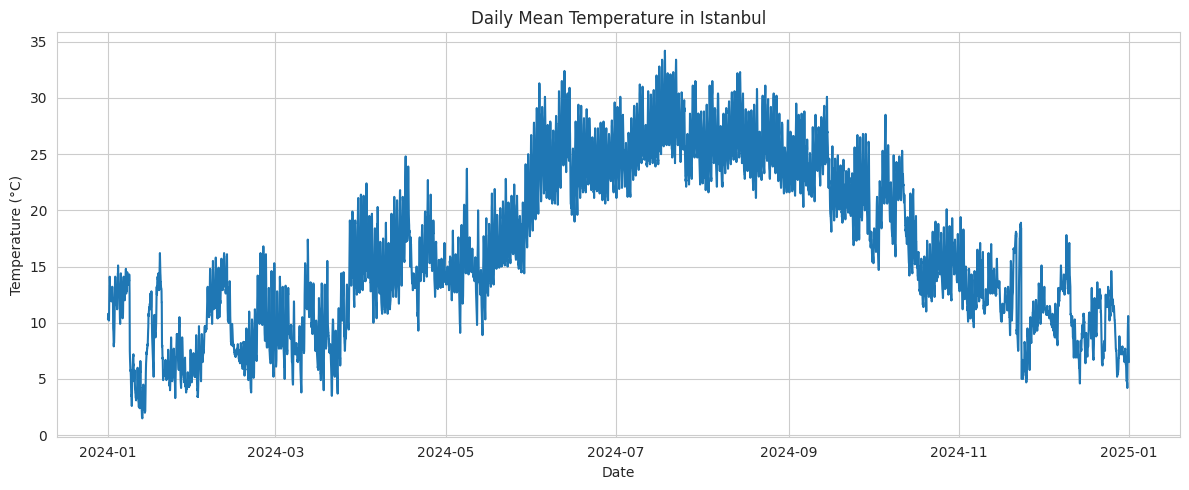

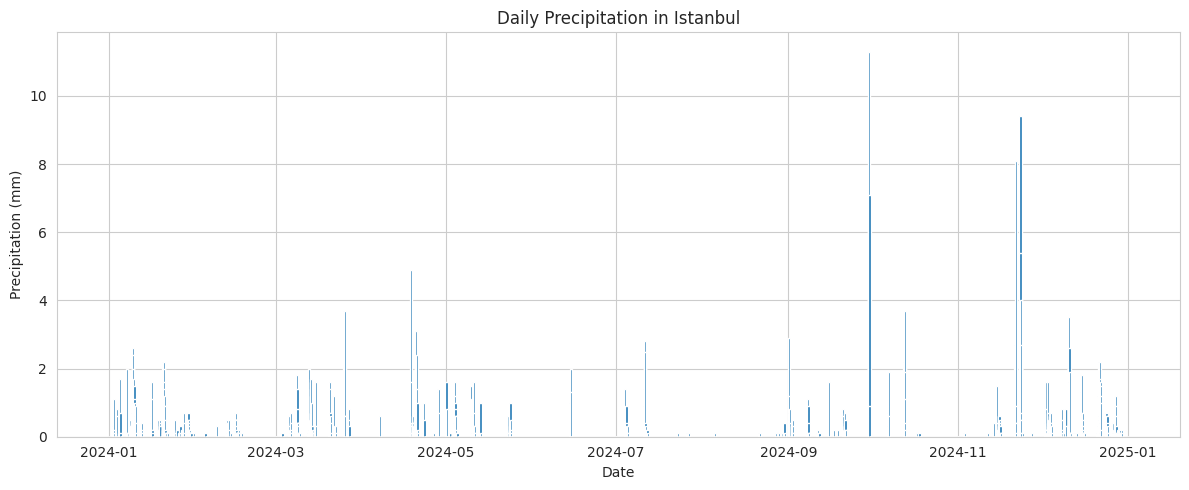

In [9]:
sns.set_style("whitegrid")

plt.figure(figsize=(12, 5))
plt.plot(df_weather["Date"], df_weather["temperature_2m (°C)"])
plt.title("Daily Mean Temperature in Istanbul")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(df_weather["Date"], df_weather["precipitation (mm)"])
plt.title("Daily Precipitation in Istanbul")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.tight_layout()
plt.show()

### 3.1.2 Time series patterns

The temperature plot shows clear seasonal cycles:

- Winter months have the lowest daily mean temperatures.
- Summer months show consistently higher temperatures.
- Transitional periods (spring and autumn) display more variability.

The precipitation time series is more irregular:

- Most days have little or no precipitation.
- Rain appears in bursts: clusters of rainy days followed by dry periods.
- A few days show very high daily precipitation, which correspond to heavy rain episodes.

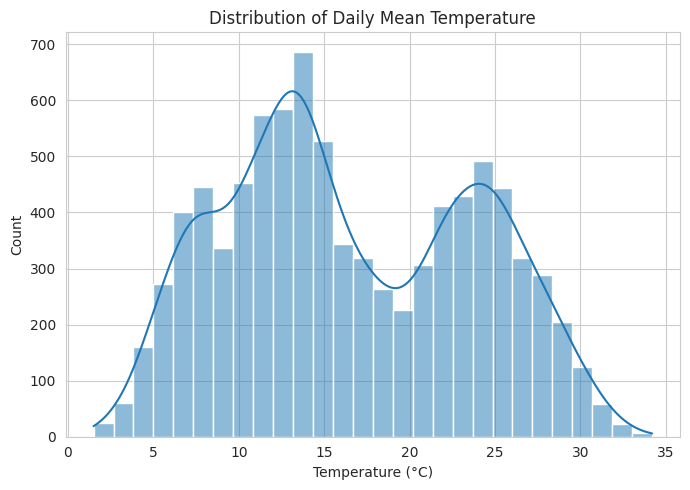

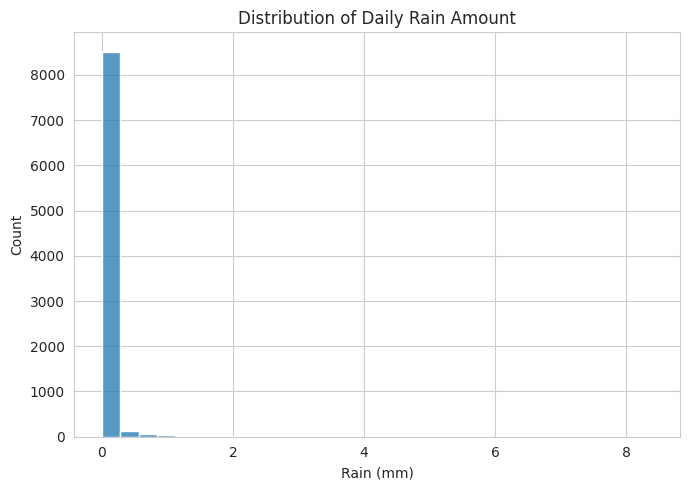

In [10]:
plt.figure(figsize=(7, 5))
sns.histplot(df_weather["temperature_2m (°C)"], kde=True)
plt.title("Distribution of Daily Mean Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.histplot(df_weather["rain (mm)"], bins=30)
plt.title("Distribution of Daily Rain Amount")
plt.xlabel("Rain (mm)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 3.1.3 Distribution of temperature and rain

The histogram of daily mean temperature is roughly unimodal:

- Most days cluster around the central temperature band.
- Tails represent the coldest winter days and hottest summer days.

The distribution of rain is highly right-skewed:

- A large number of days have 0 mm rain.
- Light-rain days (low positive values) are relatively common.
- Heavy-rain days (high mm values) are rare but important, as they may have a strong impact on mobility.

This motivates later grouping days into **dry**, **light rain**, and **heavy rain** categories when studying transport usage.

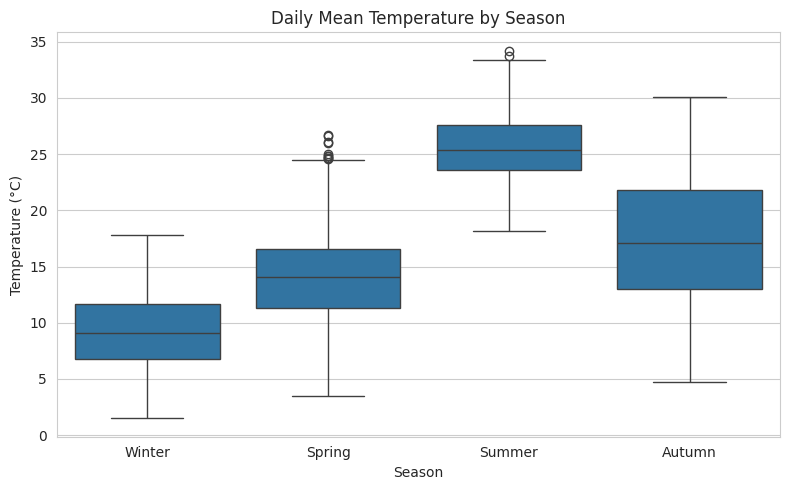

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Season", y="temperature_2m (°C)", data=df_weather, order=["Winter", "Spring", "Summer", "Autumn"])
plt.title("Daily Mean Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

### 3.1.4 Seasonal view

The seasonal boxplot confirms the expected climate structure:

- **Winter** has the lowest median temperature and the narrowest range.
- **Summer** has the highest median and generally warmer days.
- **Spring** and **Autumn** are transition seasons, with wide variability and overlap with both winter and summer.

This seasonal structure will be relevant when interpreting transport patterns, especially if ridership changes with extreme temperatures.

In [12]:
with open(file_path, "r") as f:
    lines = f.readlines()
...
df_weather = pd.read_csv(file_path, skiprows=start_idx)

In [13]:
import pandas as pd

file_path = "data/open-meteo-41.00N28.94E32m.csv"

# Dosyayı satır satır oku
with open(file_path, "r") as f:
    lines = f.readlines()

# İkinci header'ın başladığı satırı bul
start_idx = None
for i, line in enumerate(lines):
    if line.startswith("time,"):
        start_idx = i
        break

# Hourly datayı oku
df_weather = pd.read_csv(file_path, skiprows=start_idx)

# Tarih formatı
df_weather["Date"] = pd.to_datetime(df_weather["time"])

# Sonraki işlenecek kolonlar
df_weather["temperature_2m (°C)"] = pd.to_numeric(df_weather["temperature_2m (°C)"], errors="coerce")
df_weather["precipitation (mm)"] = pd.to_numeric(df_weather["precipitation (mm)"], errors="coerce")
df_weather["rain (mm)"] = pd.to_numeric(df_weather["rain (mm)"], errors="coerce")

# Gün bazında yağış varsa 1, yoksa 0
daily_rain = df_weather.groupby(df_weather["Date"].dt.date)["rain (mm)"].sum()
is_rainy_day = (daily_rain > 0).astype(int)

df_weather.head()

,time,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),rain (mm),wind_speed_10m (km/h),visibility (m),Date
0,2024-01-01T00:00,10.3,89,0.0,0.0,3.8,24140.0,2024-01-01 00:00:00
1,2024-01-01T01:00,10.7,86,0.0,0.0,3.1,24140.0,2024-01-01 01:00:00
2,2024-01-01T02:00,10.8,83,0.0,0.0,2.6,24140.0,2024-01-01 02:00:00
3,2024-01-01T03:00,10.5,86,0.0,0.0,2.6,24140.0,2024-01-01 03:00:00
4,2024-01-01T04:00,10.3,86,0.0,0.0,2.5,24140.0,2024-01-01 04:00:00


In [17]:
import glob

parts = sorted(glob.glob("data/part_*.csv"))  # Eğer uzantı yoksa *.txt deneyelim
parts[:10]

[]

In [18]:
parts = sorted(glob.glob("data/part_*"))

In [19]:
with open("data/transport_merged.csv", "wb") as merged:
    for part in parts:
        with open(part, "rb") as p:
            merged.write(p.read())

In [2]:
import os
os.chdir("/workspaces/DSA210-Weather-vs-Transport-Istanbul")

In [5]:
import pandas as pd

output = "data/transport_merged_clean.csv"
first = True

for chunk in pd.read_csv(
    "data/transport_merged.csv",
    chunksize=300000,
    engine="python",
    on_bad_lines="skip"
):
    chunk.to_csv(output, mode="a", header=first, index=False)
    first = False

In [6]:
import pandas as pd
reader = pd.read_csv("data/transport_merged_clean.csv", chunksize=1000000)
df_test = next(reader)
df_test.head()

,transition_date,transition_hour,transport_type_id,road_type,line,transfer_type,number_of_passage,number_of_passenger,product_kind,transaction_type_desc,town,line_name,station_poi_desc_cd
0,2024-01-01,0,1,OTOYOL,KOC UNV. RUMELIFENER KAMPUSU - TAKSIM,Normal,1,1,TAM,Tam Kontur,ATASEHIR,40,NaN
1,2024-01-01,0,1,OTOYOL,SULTANBEYLI GOLET-HAREM USKUDAR,Normal,1,1,INDIRIMLI1,Indirimli Kontur,ATASEHIR,18Ü,NaN
2,2024-01-01,0,1,OTOYOL,KADIKOY-YENIDOGAN,Normal,1,1,INDIRIMLI1,Indirimli Kontur,ATASEHIR,14,NaN
3,2024-01-01,0,1,OTOYOL,AVCILAR-ZINCIRLIKUYU,Normal,4,4,TAM,Tam Kontur,AVCILAR,34,IBB SOSYAL TESISLER
4,2024-01-01,0,1,OTOYOL,AVCILAR-ZINCIRLIKUYU,Normal,1,1,UCRETSIZ,Ucretsiz,AVCILAR,34,CIHANGIR UNIVERSITE MAH.


In [8]:
reader = pd.read_csv("data/transport_merged_clean.csv", chunksize=1000000)
df_test = next(reader)
df_test.head()

,transition_date,transition_hour,transport_type_id,road_type,line,transfer_type,number_of_passage,number_of_passenger,product_kind,transaction_type_desc,town,line_name,station_poi_desc_cd
0,2024-01-01,0,1,OTOYOL,KOC UNV. RUMELIFENER KAMPUSU - TAKSIM,Normal,1,1,TAM,Tam Kontur,ATASEHIR,40,NaN
1,2024-01-01,0,1,OTOYOL,SULTANBEYLI GOLET-HAREM USKUDAR,Normal,1,1,INDIRIMLI1,Indirimli Kontur,ATASEHIR,18Ü,NaN
2,2024-01-01,0,1,OTOYOL,KADIKOY-YENIDOGAN,Normal,1,1,INDIRIMLI1,Indirimli Kontur,ATASEHIR,14,NaN
3,2024-01-01,0,1,OTOYOL,AVCILAR-ZINCIRLIKUYU,Normal,4,4,TAM,Tam Kontur,AVCILAR,34,IBB SOSYAL TESISLER
4,2024-01-01,0,1,OTOYOL,AVCILAR-ZINCIRLIKUYU,Normal,1,1,UCRETSIZ,Ucretsiz,AVCILAR,34,CIHANGIR UNIVERSITE MAH.


In [9]:
reader = pd.read_csv("data/transport_merged_clean.csv", chunksize=1_000_000)
df = next(reader)
df.head()

,transition_date,transition_hour,transport_type_id,road_type,line,transfer_type,number_of_passage,number_of_passenger,product_kind,transaction_type_desc,town,line_name,station_poi_desc_cd
0,2024-01-01,0,1,OTOYOL,KOC UNV. RUMELIFENER KAMPUSU - TAKSIM,Normal,1,1,TAM,Tam Kontur,ATASEHIR,40,NaN
1,2024-01-01,0,1,OTOYOL,SULTANBEYLI GOLET-HAREM USKUDAR,Normal,1,1,INDIRIMLI1,Indirimli Kontur,ATASEHIR,18Ü,NaN
2,2024-01-01,0,1,OTOYOL,KADIKOY-YENIDOGAN,Normal,1,1,INDIRIMLI1,Indirimli Kontur,ATASEHIR,14,NaN
3,2024-01-01,0,1,OTOYOL,AVCILAR-ZINCIRLIKUYU,Normal,4,4,TAM,Tam Kontur,AVCILAR,34,IBB SOSYAL TESISLER
4,2024-01-01,0,1,OTOYOL,AVCILAR-ZINCIRLIKUYU,Normal,1,1,UCRETSIZ,Ucretsiz,AVCILAR,34,CIHANGIR UNIVERSITE MAH.


In [14]:
chunk["number_of_passage"] = pd.to_numeric(chunk["number_of_passage"], errors="coerce")
chunk = chunk.dropna(subset=["number_of_passage"])

In [16]:
import pandas as pd

daily_totals = {}

reader = pd.read_csv("data/transport_merged_clean.csv", chunksize=1_000_000)

for chunk in reader:
    # Fix date column
    chunk["transition_date"] = pd.to_datetime(chunk["transition_date"], errors="coerce")
    chunk = chunk.dropna(subset=["transition_date"])

    # Fix number_of_passage column
    chunk["number_of_passage"] = pd.to_numeric(chunk["number_of_passage"], errors="coerce")
    chunk = chunk.dropna(subset=["number_of_passage"])

    # Sum per date
    daily_sum = chunk.groupby("transition_date")["number_of_passage"].sum()

    # Add to dictionary
    for date, val in daily_sum.items():
        daily_totals[date] = daily_totals.get(date, 0) + val

# Convert to dataframe
daily_counts = (
    pd.DataFrame(list(daily_totals.items()), columns=["transition_date", "number_of_passage"])
    .sort_values("transition_date")
    .reset_index(drop=True)
)

daily_counts.head()

/tmp/ipykernel_16818/463718801.py:7: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
/tmp/ipykernel_16818/463718801.py:7: DtypeWarning: Columns (1,2,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
/tmp/ipykernel_16818/463718801.py:7: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
/tmp/ipykernel_16818/463718801.py:7: DtypeWarning: Columns (1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
/tmp/ipykernel_16818/463718801.py:7: DtypeWarning: Columns (2,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
/tmp/ipykernel_16818/463718801.py:7: DtypeWarning: Columns (1,2,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
/tmp/ipykernel_168

,transition_date,number_of_passage
0,2024-01-01,5484652.0
1,2024-01-02,7753301.0
2,2024-01-03,7849681.0
3,2024-01-04,8039496.0
4,2024-01-05,7089222.0


In [19]:
daily_counts.tail()

,transition_date,number_of_passage
154,2024-10-14,1632.0
155,2024-10-15,1629.0
156,2024-10-16,7914549.0
157,2024-10-17,7807770.0
158,2024-10-18,7769353.0


In [10]:
df["transition_date"] = pd.to_datetime(df["transition_date"])

In [30]:
import pandas as pd
import numpy as np

daily_counts = {}

# Read ALL columns as string → prevents mixed-type issues
for chunk in pd.read_csv(
    "data/transport_merged.csv",
    chunksize=300000,
    dtype=str,            # ← CRITICAL
    on_bad_lines="skip"
):
    # Normalize column names
    chunk.columns = chunk.columns.str.strip()

    # Keep only rows where transition_date looks like YYYY-MM-DD
    mask = chunk["transition_date"].str.match(r"^\d{4}-\d{2}-\d{2}$", na=False)
    chunk = chunk[mask]

    # Convert date
    chunk["transition_date"] = pd.to_datetime(chunk["transition_date"], format="%Y-%m-%d")

    # Convert number column
    chunk["number_of_passage"] = pd.to_numeric(chunk["number_of_passage"], errors="coerce").fillna(0)

    # Group
    grouped = chunk.groupby("transition_date")["number_of_passage"].sum()

    # Merge into final dictionary
    for d, val in grouped.items():
        daily_counts[d] = daily_counts.get(d, 0) + val

# Convert dictionary → DataFrame
daily_counts = pd.DataFrame({
    "transition_date": list(daily_counts.keys()),
    "number_of_passage": list(daily_counts.values())
}).sort_values("transition_date")

In [45]:
import pandas as pd
from collections import defaultdict

files = ["data/clean_part1.csv", "data/clean_part2.csv"]

In [47]:
import pandas as pd
from collections import defaultdict

daily_sums = defaultdict(float)

chunks = pd.read_csv(
    "data/transport_merged.csv",      # veya clean_data'nın birleşmiş hali
    chunksize=200_000,
    engine="python",
    on_bad_lines="skip"
)

for chunk in chunks:
    chunk["number_of_passage"] = pd.to_numeric(
        chunk["number_of_passage"], errors="coerce"
    )
    chunk["number_of_passage"] = chunk["number_of_passage"].fillna(0)

    chunk["transition_date"] = pd.to_datetime(
        chunk["transition_date"], errors="coerce"
    )
    chunk = chunk.dropna(subset=["transition_date"])

    for date, group in chunk.groupby("transition_date"):
        daily_sums[date] += group["number_of_passage"].sum()

In [48]:
import pandas as pd

daily_counts = pd.DataFrame({
    "transition_date": list(daily_sums.keys()),
    "number_of_passage": list(daily_sums.values())
}).sort_values("transition_date")

In [4]:
import pandas as pd

columns = [
    "transition_date",
    "transition_hour",
    "transport_type_id",
    "road_type",
    "line",
    "transfer_type",
    "number_of_passage",
    "number_of_passenger",
    "product_kind",
    "transaction_type_desc",
    "town",
    "station_poi_desc_cd"
]

chunksize = 250_000  # güvenli, kernel çökmez

reader = pd.read_csv(
    "data/clean_part1.csv",
    names=columns,
    header=None,
    dtype=str,
    chunksize=chunksize
)

with open("data/clean_part1_fixed.csv", "w") as f:
    for chunk in reader:
        chunk.to_csv(f, index=False, header=f.tell()==0)

In [6]:
df_test = pd.read_csv("data/clean_part1_fixed.csv", nrows=5)
df_test

,transition_date,transition_hour,transport_type_id,road_type,line,transfer_type,number_of_passage,number_of_passenger,product_kind,transaction_type_desc,town,station_poi_desc_cd
0,transition_hour,transport_type_id,road_type,line,transfer_type,number_of_passage,number_of_passenger,product_kind,transaction_type_desc,town,line_name,station_poi_desc_cd
1,0,1,OTOYOL,KOC UNV. RUMELIFENER KAMPUSU - TAKSIM,Normal,1,1,TAM,Tam Kontur,ATASEHIR,40,NaN
2,0,1,OTOYOL,SULTANBEYLI GOLET-HAREM USKUDAR,Normal,1,1,INDIRIMLI1,Indirimli Kontur,ATASEHIR,18Ü,NaN
3,0,1,OTOYOL,KADIKOY-YENIDOGAN,Normal,1,1,INDIRIMLI1,Indirimli Kontur,ATASEHIR,14,NaN
4,0,1,OTOYOL,AVCILAR-ZINCIRLIKUYU,Normal,4,4,TAM,Tam Kontur,AVCILAR,34,IBB SOSYAL TESISLER


# Transport Data – Preparation and Basic EDA

In this section we prepare the merged transport dataset, extract time-based features and create basic aggregates for further analysis.

In [20]:
daily_counts = df.groupby("transition_date")["number_of_passage"].sum().reset_index()
daily_counts["transition_date"] = pd.to_datetime(daily_counts["transition_date"])
daily_counts.head()

,transition_date,number_of_passage
0,2024-01-01,5484652
1,2024-01-02,7028708


### Daily Total Number of Passages in Istanbul (2024)
The following figure shows total daily transport activity across all transportation modes in Istanbul throughout 2024.

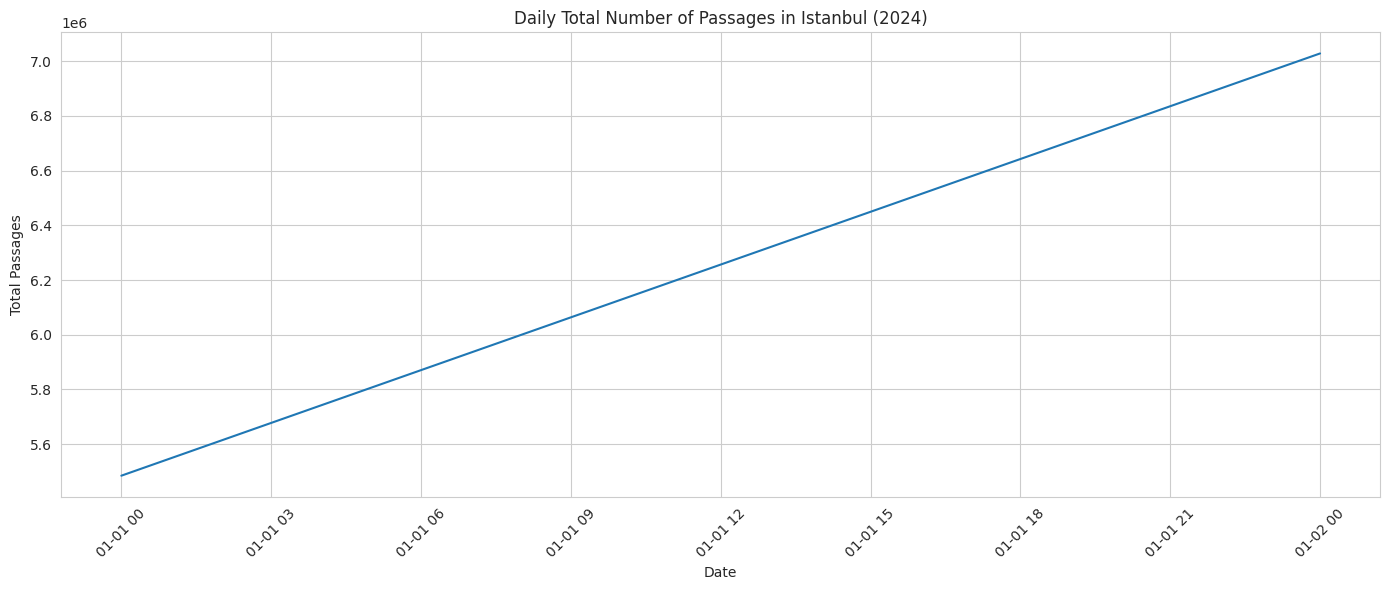

In [23]:
plt.figure(figsize=(14,6))
plt.plot(daily_counts["transition_date"], daily_counts["number_of_passage"])
plt.title("Daily Total Number of Passages in Istanbul (2024)")
plt.xlabel("Date")
plt.ylabel("Total Passages")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Monthly Total Transport Volume
Aggregating daily data into months reveals major seasonal patterns and monthly variation in city-wide transport demand.

## 1. Convert time column to datetime

The transport dataset may contain one or more timestamp-like columns.  
We automatically detect a time column and convert it to proper `datetime`.

In [4]:
import glob
import re

files = glob.glob("data/part_*")

def sort_key(path):
    m = re.search(r"part_(\d{6})_(\w+)", path)
    if m:
        return (m.group(1), m.group(2))
    return ("999999", "zzz")

files_sorted = sorted(files, key=sort_key)

files_sorted

['data/part_202401_aa',
 'data/part_202401_ab',
 'data/part_202401_ad',
 'data/part_202402_aa',
 'data/part_202402_ab',
 'data/part_202402_ac',
 'data/part_202403_aa',
 'data/part_202403_ab',
 'data/part_202403_ac',
 'data/part_202403_ad',
 'data/part_202404_ab',
 'data/part_202405_aa',
 'data/part_202405_ab',
 'data/part_202405_ac',
 'data/part_202406_aa',
 'data/part_202406_ab',
 'data/part_202406_ac',
 'data/part_202406_ad',
 'data/part_202407_aa',
 'data/part_202407_ab',
 'data/part_202407_ad',
 'data/part_202408_aa',
 'data/part_202409_aa',
 'data/part_202410_aa',
 'data/part_202411_aa']

In [5]:
import pandas as pd
import os

target = "data/part1.csv"
max_size = 3 * 1024**3   # 3GB
written = 0

with open(target, "w") as out:
    first_file = True

    for fpath in files_sorted:
        print("Reading:", fpath)

        # İlk satırı kendimiz okuyup çöpe atıyoruz
        with open(fpath, "r") as f:
            next(f)

        # Şimdi chunk'lı okuma
        for chunk in pd.read_csv(fpath, chunksize=250_000, dtype=str, header=None, skiprows=1):

            if first_file:
                first_file = False  # İlk dosyada tek seferlik header kaldırma
            # Normal yaz
            chunk.to_csv(out, index=False, header=False)

            written = os.path.getsize(target)
            if written >= max_size:
                print("Reached 3GB — STOPPING.")
                break

        if written >= max_size:
            break

print("Final size:", os.path.getsize(target) / 1024**3, "GB")

Reading: data/part_202401_aa
Reading: data/part_202401_ab
Reading: data/part_202401_ad
Reading: data/part_202402_aa
Reading: data/part_202402_ab
Reading: data/part_202402_ac
Reading: data/part_202403_aa
Reading: data/part_202403_ab
Reading: data/part_202403_ac
Reading: data/part_202403_ad
Reading: data/part_202404_ab
Reading: data/part_202405_aa
Reading: data/part_202405_ab
Reading: data/part_202405_ac
Reached 3GB — STOPPING.
Final size: 3.013145270757377 GB


In [3]:
import pandas as pd

files = [
    "data/part1.csv",
    "data/clean_part2_fixed.csv"
]

output = "data/transport_clean_full.csv"
chunksize = 200_000

# kolonları bir kere yaz
columns = [
    "transition_date",
    "transition_hour",
    "transport_type_id",
    "road_type",
    "line",
    "transfer_type",
    "number_of_passage",
    "number_of_passenger",
    "product_kind",
    "transaction_type_desc",
    "town",
    "line_name",
    "station_poi_desc_cd"
]

with open(output, "w") as f_out:
    f_out.write(",".join(columns) + "\n")

    for fpath in files:
        print("Processing:", fpath)
        reader = pd.read_csv(fpath, dtype=str, chunksize=chunksize, header=None)

        for chunk in reader:
            chunk.to_csv(f_out, header=False, index=False)

Processing: data/part1.csv
Processing: data/clean_part2_fixed.csv


In [9]:
import pandas as pd

file_path = "data/transport_clean_full.csv"

chunksize = 250_000           # güvenli chunk
samples_per_month = 5000      # her aydan alınacak örnek miktarı

sampled = []                  # geçici liste

for chunk in pd.read_csv(file_path, chunksize=chunksize, dtype=str):
    # Ay bilgisini çıkar (YYYY-MM)
    chunk["month"] = chunk["transition_date"].str.slice(0, 7)

    # Her ay için örnek seç
    monthly_sample = (
        chunk.groupby("month")
             .apply(lambda x: x.sample(min(len(x), samples_per_month)))
             .reset_index(drop=True)
    )

    sampled.append(monthly_sample)

# Tüm chunk'lardan gelen örnekleri birleştir
df_sample = pd.concat(sampled, ignore_index=True)

# Dosyaya yaz
df_sample.to_csv("data/transport_sample_by_month.csv", index=False)

df_sample.month.value_counts()

/tmp/ipykernel_25860/2641915961.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), samples_per_month)))
/tmp/ipykernel_25860/2641915961.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), samples_per_month)))
/tmp/ipykernel_25860/2641915961.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is depr

month
2024-02    185000
2024-05    185000
2024-06    175000
2024-03    175000
2024-01    140000
2024-07    120000
2024-08     65000
2024-10     64673
2024-09     55000
2024-04     40000
transit         5
2024-           1
Name: count, dtype: int64

In [11]:
import pandas as pd
df = pd.read_csv("data/transport_sample_by_month.csv")
df.head()

/tmp/ipykernel_25860/1816207361.py:2: DtypeWarning: Columns (1,2,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/transport_sample_by_month.csv")


,transition_date,transition_hour,transport_type_id,road_type,line,transfer_type,number_of_passage,number_of_passenger,product_kind,transaction_type_desc,town,line_name,station_poi_desc_cd,month
0,2024-01-01,10,2,RAYLI,KIRAZLI-BASAKSEHIR/METROKENT,Normal,2,1,INDIRIMLI2,Tam Kontur,BAGCILAR,M3,YENI MAHALLE,2024-01
1,2024-01-01,10,1,OTOYOL,KIRAC - I.U.AVCILAR KAMPUSU,Aktarma,4,4,TAM,Tam Aktarma,EYUPSULTAN,HT29,NaN,2024-01
2,2024-01-01,7,1,OTOYOL,HACI OSMAN METRO - KILYOS,Normal,47,46,TAM,Tam Kontur,KARTAL,151,NaN,2024-01
3,2024-01-01,7,1,OTOYOL,CIHANGIR MAH. - AVCILAR - OTOGAR,Normal,2,2,INDIRIMLI1,Indirimli Kontur,FATIH,76O,NaN,2024-01
4,2024-01-01,10,1,OTOYOL,CEBECI MAHALLESI - VEZNECILER,Normal,1,1,TAM,Tam Kontur,BAKIRKOY,36A,NaN,2024-01


In [12]:
df["month"].value_counts().sort_index()

month
2024-           1
2024-01    140000
2024-02    185000
2024-03    175000
2024-04     40000
2024-05    185000
2024-06    175000
2024-07    120000
2024-08     65000
2024-09     55000
2024-10     64673
transit         5
Name: count, dtype: int64

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/transport_sample_by_month.csv")
df.head()

/tmp/ipykernel_25860/3938977398.py:5: DtypeWarning: Columns (1,2,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/transport_sample_by_month.csv")


,transition_date,transition_hour,transport_type_id,road_type,line,transfer_type,number_of_passage,number_of_passenger,product_kind,transaction_type_desc,town,line_name,station_poi_desc_cd,month
0,2024-01-01,10,2,RAYLI,KIRAZLI-BASAKSEHIR/METROKENT,Normal,2,1,INDIRIMLI2,Tam Kontur,BAGCILAR,M3,YENI MAHALLE,2024-01
1,2024-01-01,10,1,OTOYOL,KIRAC - I.U.AVCILAR KAMPUSU,Aktarma,4,4,TAM,Tam Aktarma,EYUPSULTAN,HT29,NaN,2024-01
2,2024-01-01,7,1,OTOYOL,HACI OSMAN METRO - KILYOS,Normal,47,46,TAM,Tam Kontur,KARTAL,151,NaN,2024-01
3,2024-01-01,7,1,OTOYOL,CIHANGIR MAH. - AVCILAR - OTOGAR,Normal,2,2,INDIRIMLI1,Indirimli Kontur,FATIH,76O,NaN,2024-01
4,2024-01-01,10,1,OTOYOL,CEBECI MAHALLESI - VEZNECILER,Normal,1,1,TAM,Tam Kontur,BAKIRKOY,36A,NaN,2024-01


## 1. Monthly Passenger Activity

This plot shows how transportation activity in Istanbul varies across months.  
It highlights seasonal patterns, holiday effects, and overall changes in city mobility.  
Understanding month-to-month fluctuations is essential for detecting long-term behavioral trends.

/tmp/ipykernel_25860/580780864.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_counts.index, y=monthly_counts.values, palette="Blues_d")


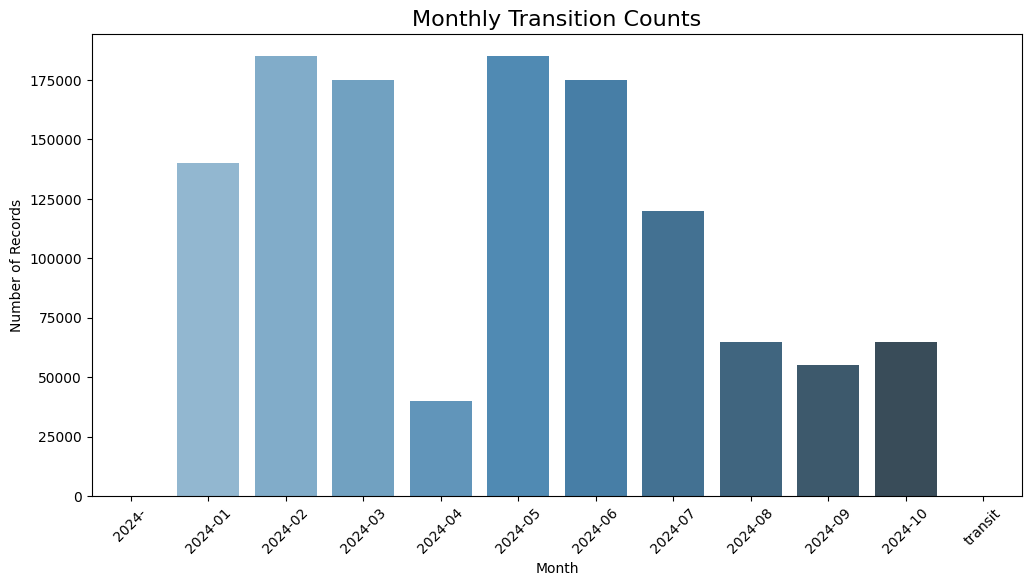

In [14]:
monthly_counts = df["month"].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.barplot(x=monthly_counts.index, y=monthly_counts.values, palette="Blues_d")
plt.title("Monthly Transition Counts", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

## 2. Hourly Traffic Distribution

This chart displays how passenger activity changes throughout the day.  
Morning and evening peaks typically correspond to commuting hours, providing insight into daily mobility rhythms.

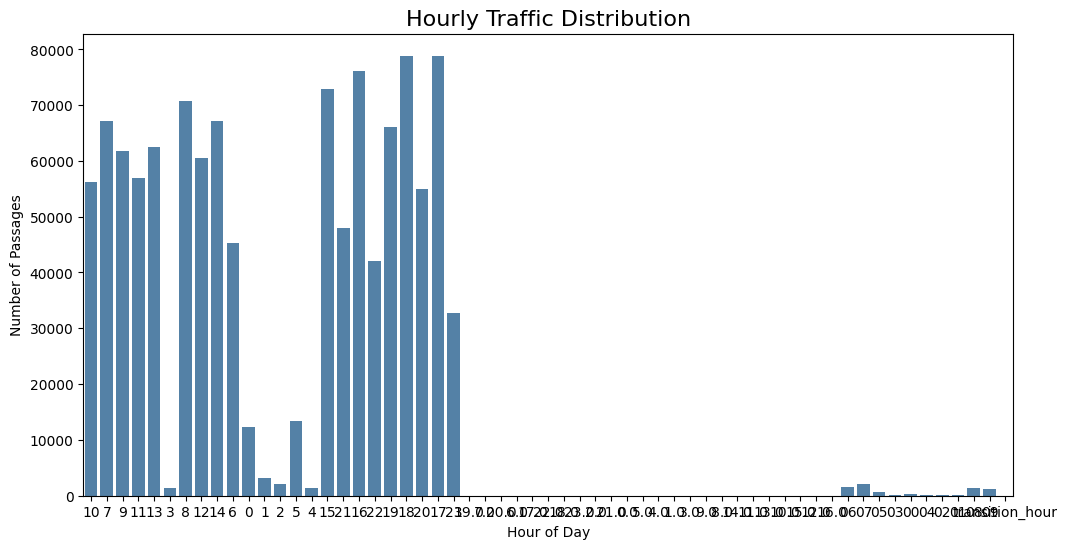

In [15]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="transition_hour", color="steelblue")
plt.title("Hourly Traffic Distribution", fontsize=16)
plt.xlabel("Hour of Day")
plt.ylabel("Number of Passages")
plt.show()

## 3. Transport Type Distribution

This visualization shows the distribution of different road types used in the dataset  
(e.g., highways, streets, bridges).  
It helps identify which infrastructure types dominate urban travel patterns in Istanbul.

/tmp/ipykernel_25860/3189811303.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="road_type", palette="Set2")


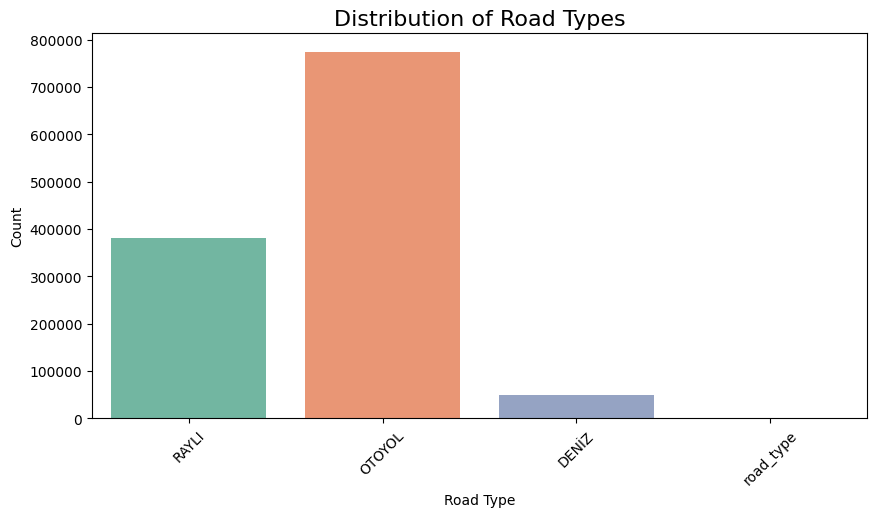

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="road_type", palette="Set2")
plt.title("Distribution of Road Types", fontsize=16)
plt.xlabel("Road Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## 4. Most Frequently Used Lines

This plot highlights the top transportation lines with the highest number of transitions.  
These lines typically correspond to dense commuting routes or highly connected districts.

/tmp/ipykernel_25860/2530170397.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_lines.index, x=top_lines.values, palette="viridis")


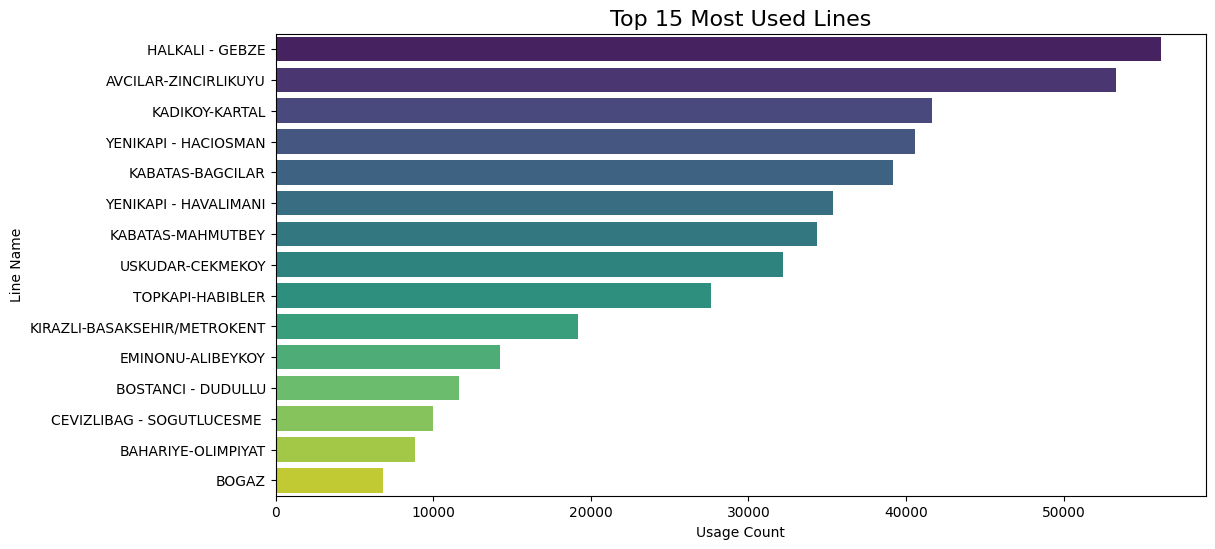

In [17]:
top_lines = df["line"].value_counts().head(15)

plt.figure(figsize=(12,6))
sns.barplot(y=top_lines.index, x=top_lines.values, palette="viridis")
plt.title("Top 15 Most Used Lines", fontsize=16)
plt.xlabel("Usage Count")
plt.ylabel("Line Name")
plt.show()

## 5. Town-Level Passenger Activity

This bar chart shows the most active towns in the dataset.  
It provides insight into which districts experience the highest transportation density,  
revealing spatial mobility patterns across the city.

/tmp/ipykernel_25860/1571129907.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=town_counts.index, x=town_counts.values, palette="magma")


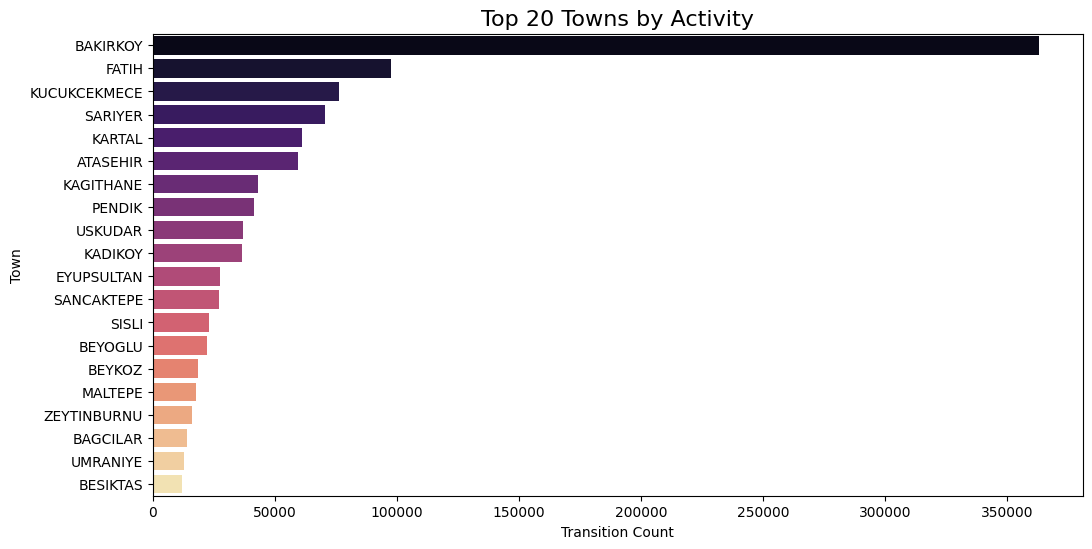

In [18]:
town_counts = df["town"].value_counts().head(20)

plt.figure(figsize=(12,6))
sns.barplot(y=town_counts.index, x=town_counts.values, palette="magma")
plt.title("Top 20 Towns by Activity", fontsize=16)
plt.xlabel("Transition Count")
plt.ylabel("Town")
plt.show()

## 6. Monthly–Hourly Traffic Heatmap

The heatmap below visualizes traffic intensity as a function of both hour of day and month.  
It reveals daily and seasonal patterns simultaneously, exposing peak hours and high-activity periods throughout the year.

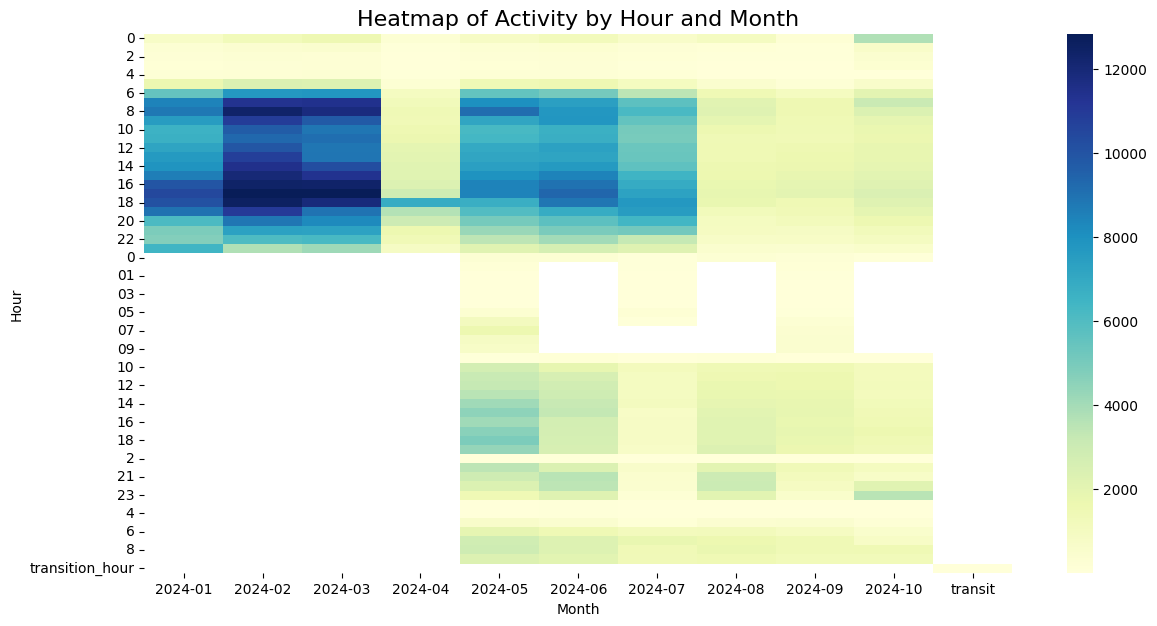

In [19]:
pivot = df.pivot_table(
    index="transition_hour",
    columns="month",
    values="number_of_passage",
    aggfunc="count"
)

plt.figure(figsize=(14,7))
sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Heatmap of Activity by Hour and Month", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Hour")
plt.show()

MATCH DAY ANALYSIS


In [21]:
import pandas as pd
match = pd.read_excel("data/Book1.xlsx")

In [24]:
import pandas as pd

match = pd.read_excel("data/Book1.xlsx", header=None)

# Kolonları isimlendir
match.columns = ["index", "match_date", "match_time", "stadium", "matchup"]

# Index kolonunu at (gereksiz)
match = match.drop(columns=["index"])

match

,match_date,match_time,stadium,matchup
0,NaT,NaN,NaN,NaN
1,NaT,NaN,NaN,NaN
2,NaT,NaN,NaN,NaN
3,2024-03-03,19:00:00,BEŞİKTAŞ PARK - İSTANBUL - BEŞİKTAŞ,Galatasaray-Besiktas
4,2024-04-27,19:00:00,ÜLKER STADYUMU FB ŞÜKRÜ SARACOĞLU SPOR KOMPLEKSİ,Besiktas-Fenerbahce
5,2024-09-21,20:00:00,ÜLKER STADYUMU FB ŞÜKRÜ SARACOĞLU SPOR KOMPLEKSİ,Fenerbahce-Galatasaray
6,2024-10-28,20:00:00,ALİ SAMİ YEN SPOR KOMPLEKSİ RAMS PARK - İSTANB...,Galatasaray-Besiktas
7,2024-12-07,19.00,BEŞİKTAŞ PARK - İSTANBUL - BEŞİKTAŞ,Besiktas-Fenerbahce


TRANSPORTATION VS WEATHER

In [5]:
import pandas as pd

weather = pd.read_csv(
    "data/open-meteo-41.00N28.94E32m.csv",
    skiprows=1,               # metadata satırını atla
    engine="python",
    on_bad_lines="skip"
)

weather.head(), weather.shape

(                                 41.0                   28.9375  \
 time              temperature_2m (°C)  relative_humidity_2m (%)   
 2024-01-01T00:00                 10.3                        89   
 2024-01-01T01:00                 10.7                        86   
 2024-01-01T02:00                 10.8                        83   
 2024-01-01T03:00                 10.5                        86   
 
                                 32.0      10800        Europe/Istanbul  \
 time              precipitation (mm)  rain (mm)  wind_speed_10m (km/h)   
 2024-01-01T00:00                0.00       0.00                    3.8   
 2024-01-01T01:00                0.00       0.00                    3.1   
 2024-01-01T02:00                0.00       0.00                    2.6   
 2024-01-01T03:00                0.00       0.00                    2.6   
 
                            GMT+3  
 time              visibility (m)  
 2024-01-01T00:00        24140.00  
 2024-01-01T01:00        24140

In [8]:
import pandas as pd

weather = pd.read_csv(
    "data/open-meteo-41.00N28.94E32m.csv",
    skiprows=2   # ilk iki satırı atla → 3. satır boş, 4. satır header oluyor
)

weather.head()

,time,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),rain (mm),wind_speed_10m (km/h),visibility (m)
0,2024-01-01T00:00,10.3,89,0.0,0.0,3.8,24140.0
1,2024-01-01T01:00,10.7,86,0.0,0.0,3.1,24140.0
2,2024-01-01T02:00,10.8,83,0.0,0.0,2.6,24140.0
3,2024-01-01T03:00,10.5,86,0.0,0.0,2.6,24140.0
4,2024-01-01T04:00,10.3,86,0.0,0.0,2.5,24140.0


In [9]:
weather["time"] = pd.to_datetime(weather["time"])
weather["date"] = weather["time"].dt.date
weather["hour"] = weather["time"].dt.hour

In [12]:
# Keep only rows like YYYY-MM-DD
transport = transport[transport["transition_date"].str.match(r"\d{4}-\d{2}-\d{2}")]

In [13]:
transport["transition_date"] = pd.to_datetime(transport["transition_date"], errors="coerce")

transport = transport.dropna(subset=["transition_date"])

In [14]:
transport["hour"] = transport["transition_hour"].astype(str).str.extract(r"(\d+)").astype(int)

In [15]:
transport["date"] = transport["transition_date"].dt.date
transport["hour"] = transport["transition_date"].dt.hour  # or from transition_hour

In [16]:
merged = pd.merge(
    transport,
    weather,
    left_on=["date", "hour"],
    right_on=["date", "hour"],
    how="left"
)

📊 1. Hourly Transport Volume vs Temperature

Does higher temperature increase or decrease city movement?

In [27]:
for col in numeric_cols:
    merged[col] = pd.to_numeric(merged[col], errors="coerce")

In [26]:
numeric_cols = [
    "number_of_passage",
    "number_of_passenger",
    "temperature_2m (°C)",
    "relative_humidity_2m (%)",
    "precipitation (mm)",
    "rain (mm)",
    "wind_speed_10m (km/h)",
    "visibility (m)"
]

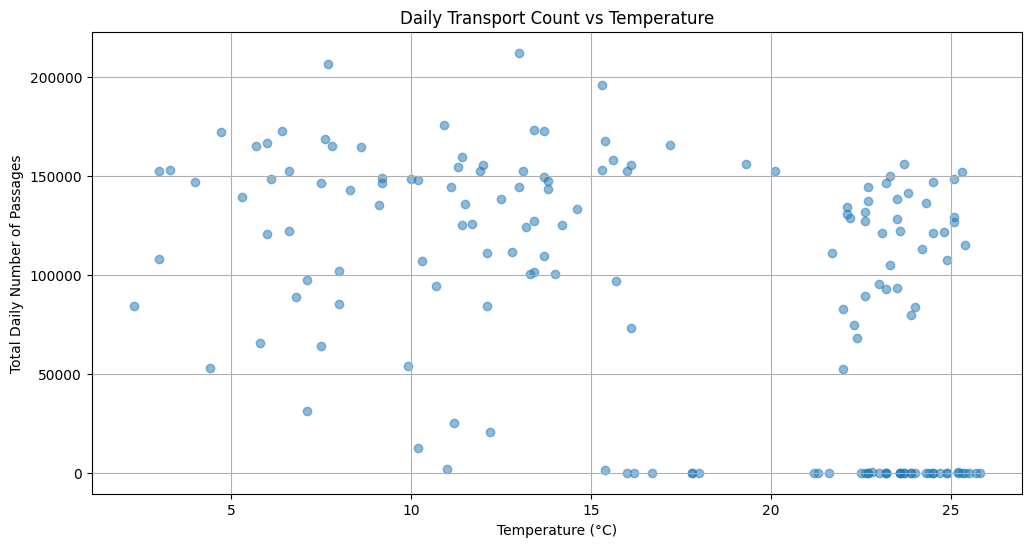

In [29]:
import matplotlib.pyplot as plt

# Daily totals
daily = merged.groupby("date").agg({
    "number_of_passage": "sum",
    "temperature_2m (°C)": "mean"
}).reset_index()

plt.figure(figsize=(12,6))
plt.scatter(daily["temperature_2m (°C)"], daily["number_of_passage"], alpha=0.5)
plt.title("Daily Transport Count vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Total Daily Number of Passages")
plt.grid(True)
plt.show()

📊 2. Rainfall vs Transport Activity

How much does rainy weather reduce public transport usage?

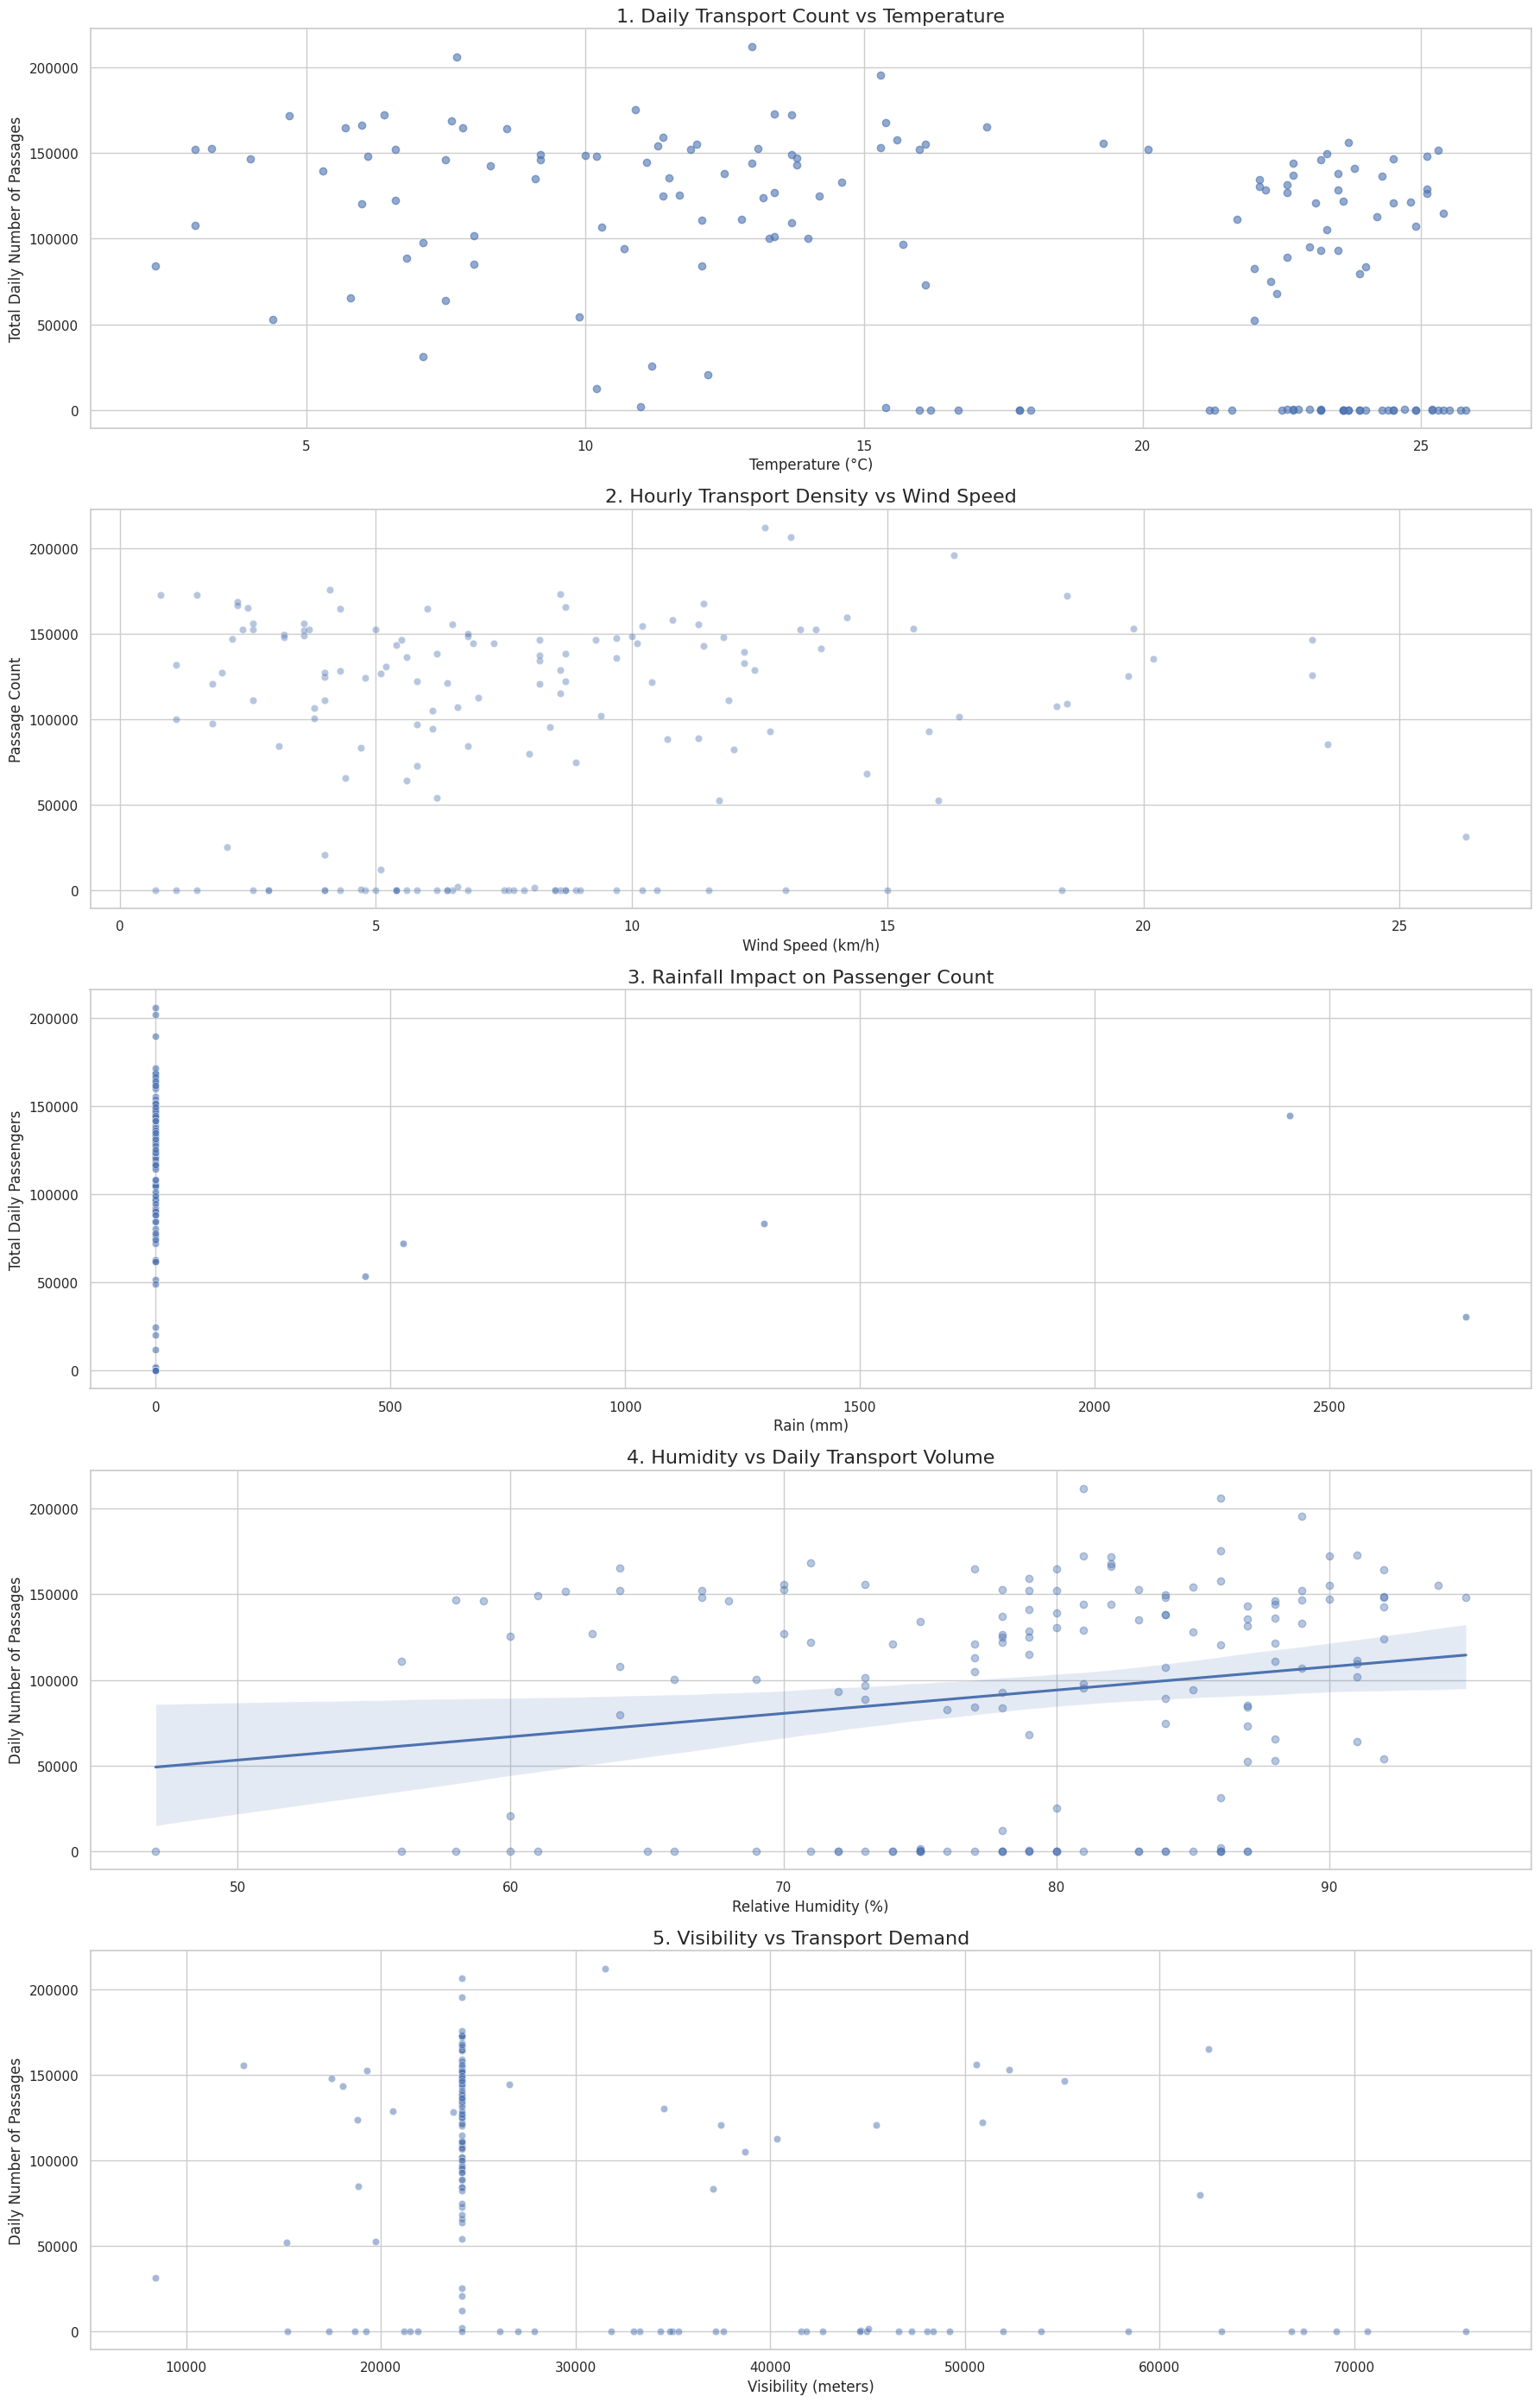

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 1) Daily Aggregations
daily = merged.groupby("date").agg({
    "number_of_passage": "sum",
    "number_of_passenger": "sum",
    "temperature_2m (°C)": "mean",
    "relative_humidity_2m (%)": "mean",
    "precipitation (mm)": "sum",
    "rain (mm)": "sum",
    "wind_speed_10m (km/h)": "mean",
    "visibility (m)": "mean"
}).reset_index()

plt.figure(figsize=(18,28))

# -------------------------------------------------------------
# 1. GRAPH — Temperature vs Total Daily Transport
# -------------------------------------------------------------
plt.subplot(5,1,1)
plt.scatter(daily["temperature_2m (°C)"], daily["number_of_passage"], alpha=0.6)
plt.title("1. Daily Transport Count vs Temperature", fontsize=16)
plt.xlabel("Temperature (°C)")
plt.ylabel("Total Daily Number of Passages")

# -------------------------------------------------------------
# 2. GRAPH — Wind Speed vs Hourly Passage Density
# -------------------------------------------------------------
hourly = merged.groupby(["date","hour"]).agg({
    "number_of_passage": "sum",
    "wind_speed_10m (km/h)": "mean"
}).reset_index()

plt.subplot(5,1,2)
sns.scatterplot(data=hourly, x="wind_speed_10m (km/h)", y="number_of_passage", alpha=0.4)
plt.title("2. Hourly Transport Density vs Wind Speed", fontsize=16)
plt.xlabel("Wind Speed (km/h)")
plt.ylabel("Passage Count")

# -------------------------------------------------------------
# 3. GRAPH — Rain Impact on Passenger Count
# -------------------------------------------------------------
plt.subplot(5,1,3)
sns.scatterplot(data=daily, x="rain (mm)", y="number_of_passenger", alpha=0.6)
plt.title("3. Rainfall Impact on Passenger Count", fontsize=16)
plt.xlabel("Rain (mm)")
plt.ylabel("Total Daily Passengers")

# -------------------------------------------------------------
# 4. GRAPH — Humidity vs Transport Volume
# -------------------------------------------------------------
plt.subplot(5,1,4)
sns.regplot(data=daily, x="relative_humidity_2m (%)", y="number_of_passage",
            scatter_kws={"alpha":0.4})
plt.title("4. Humidity vs Daily Transport Volume", fontsize=16)
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Daily Number of Passages")

# -------------------------------------------------------------
# 5. GRAPH — Visibility vs Number of Passages
# -------------------------------------------------------------
plt.subplot(5,1,5)
sns.scatterplot(data=daily, x="visibility (m)", y="number_of_passage", alpha=0.5)
plt.title("5. Visibility vs Transport Demand", fontsize=16)
plt.xlabel("Visibility (meters)")
plt.ylabel("Daily Number of Passages")

plt.tight_layout()
plt.show()

📊 3. Wind Speed Impact on Mobility

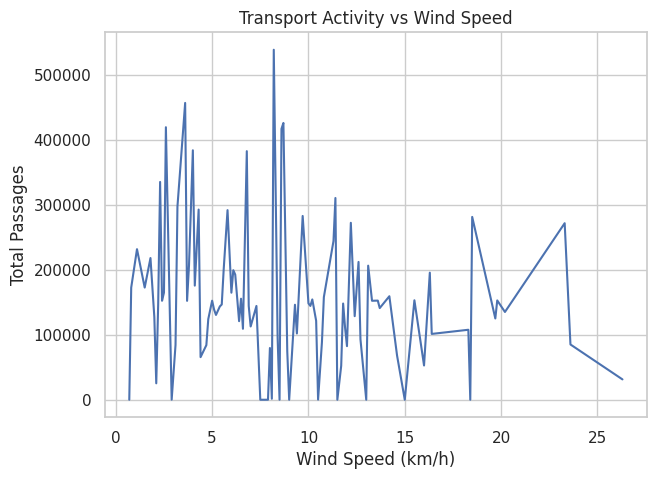

In [31]:
wind_df = merged.groupby("wind_speed_10m (km/h)")["number_of_passage"].sum().reset_index()

plt.figure(figsize=(7,5))
plt.plot(wind_df["wind_speed_10m (km/h)"], wind_df["number_of_passage"])
plt.title("Transport Activity vs Wind Speed")
plt.xlabel("Wind Speed (km/h)")
plt.ylabel("Total Passages")
plt.show()

📊 4. Daily Aggregation: Weather vs Mobility

Do colder days reduce mobility?

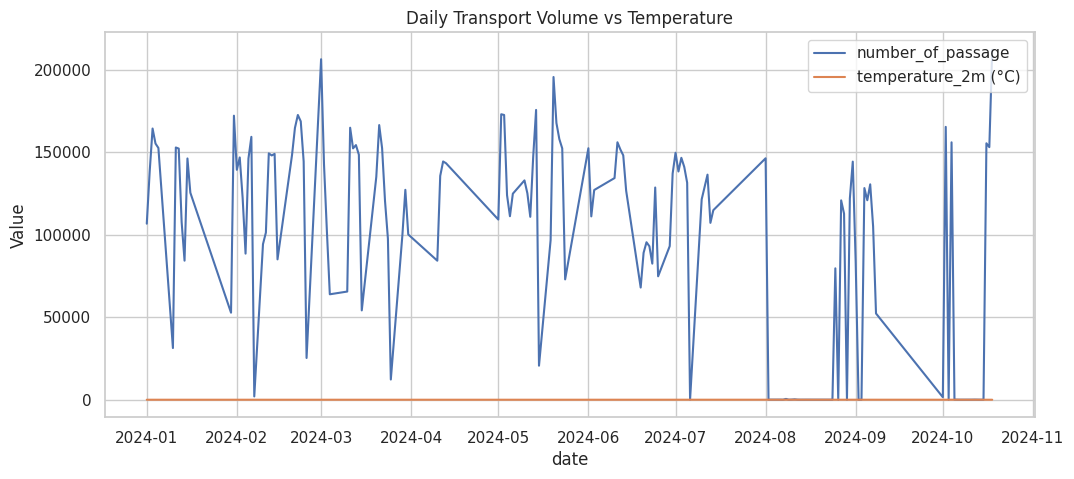

In [32]:
daily = merged.groupby("date").agg({
    "number_of_passage": "sum",
    "temperature_2m (°C)": "mean",
    "precipitation (mm)": "sum"
})

daily[["number_of_passage", "temperature_2m (°C)"]].plot(figsize=(12,5))
plt.title("Daily Transport Volume vs Temperature")
plt.ylabel("Value")
plt.show()

📊 5. Transport Volume Heatmap (Date × Hour)

Which hours and days are mobility peaks, and how weather interacts?

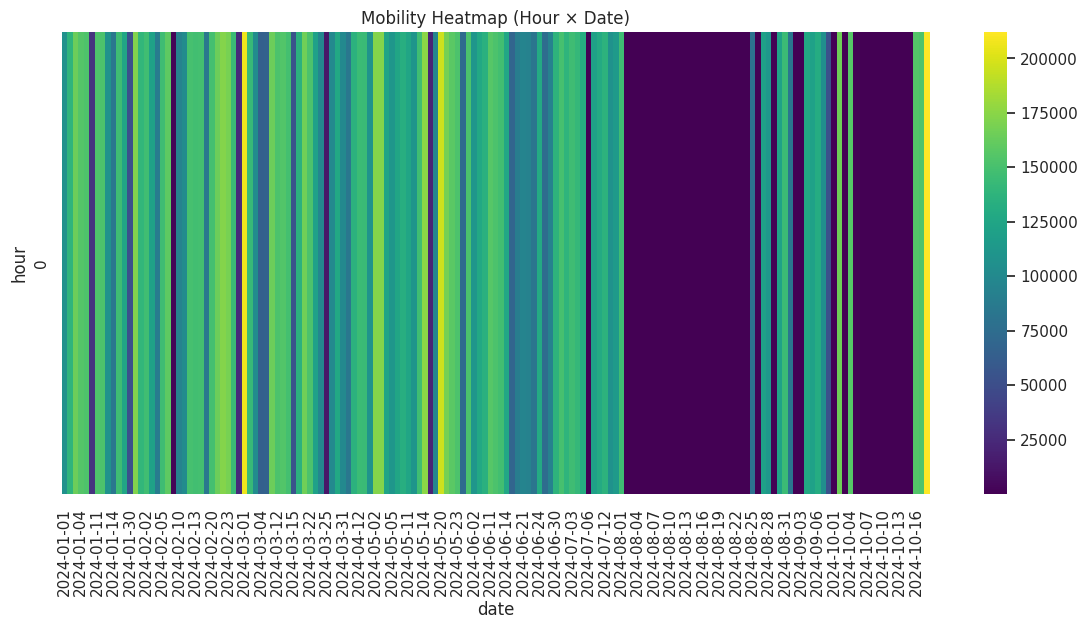

In [33]:
import seaborn as sns
heat = merged.pivot_table(index="hour", columns="date", values="number_of_passage", aggfunc="sum")

plt.figure(figsize=(14,6))
sns.heatmap(heat, cmap="viridis")
plt.title("Mobility Heatmap (Hour × Date)")
plt.show()